# Практика: Снижение размерности — PCA, t-SNE и UMAP

## Что вы сделаете
В этом ноутбуке вы:

1. загрузите и исследуете датасет `digits` (рукописные цифры);
2. примените **PCA** как препроцессинг: выберете число компонент по cumulative EVR;
3. проинтерпретируете главные компоненты через **loadings**;
4. обучите классификатор на PCA-признаках и сравните с обучением на исходных признаках;
5. визуализируете структуру данных через **t-SNE** и **UMAP**;
6. сравните 2D-проекции PCA, t-SNE и UMAP: насколько хорошо разделяются классы?

## Датасет
Мы используем `digits` из `sklearn.datasets`:
- 1797 изображений рукописных цифр 0–9;
- каждое изображение — 8×8 пикселей = **64 признака** (интенсивность пикселей);
- задача: 10-классовая классификация.

## Что сдавать
1. Заполненный ноутбук со всем кодом.
2. Краткие выводы в конце:
   - сколько компонент PCA достаточно для сохранения 95% дисперсии?
   - как влияет PCA-препроцессинг на качество классификатора?
   - какой метод визуализации (PCA, t-SNE, UMAP) лучше разделяет классы?

---
## Шаг 1. Загрузка и первичный анализ данных

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

digits = load_digits()
X = digits.data
y = digits.target

print(f"Форма X: {X.shape}")
print(f"Классы: {np.unique(y)}")
print(f"Признаки: {X.shape[1]} (8x8 пикселей)")

Форма X: (1797, 64)
Классы: [0 1 2 3 4 5 6 7 8 9]
Признаки: 64 (8x8 пикселей)


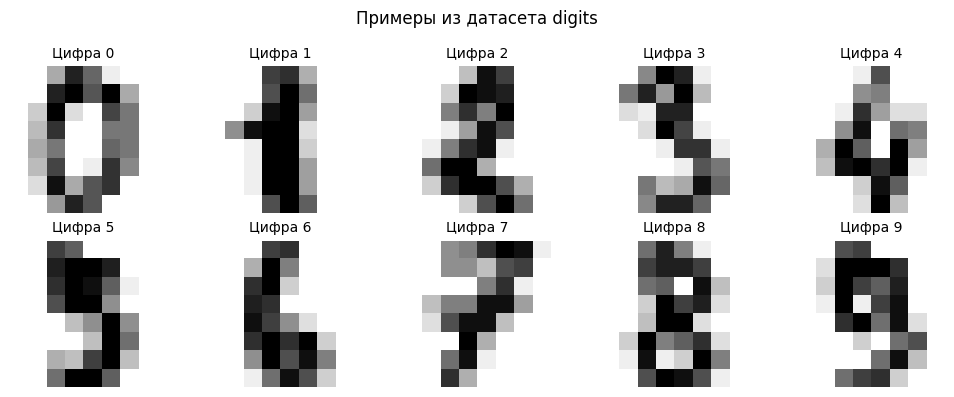

In [38]:
# Визуализируем примеры из каждого класса
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, idx in zip(axes.flat, range(10)):
    sample_idx = np.where(y == idx)[0][0]
    ax.imshow(X[sample_idx].reshape(8, 8), cmap='gray_r')
    ax.set_title(f'Цифра {idx}', fontsize=10)
    ax.axis('off')
plt.suptitle('Примеры из датасета digits', fontsize=12)
plt.tight_layout()
plt.show()

In [39]:
# Стандартизация — обязательный шаг перед PCA!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Среднее до: {X.mean():.2f}, после: {X_scaled.mean():.4f}")
print(f"Std до: {X.std():.2f}, после: {X_scaled.std():.4f}")

Среднее до: 4.88, после: 0.0000
Std до: 6.02, после: 0.9763


---
## Шаг 2. PCA: explained variance и выбор числа компонент

Обучите PCA на всех 64 компонентах. Постройте график накопленной объясняемой дисперсии.
Определите, сколько компонент нужно для сохранения 80%, 95% и 99% дисперсии.

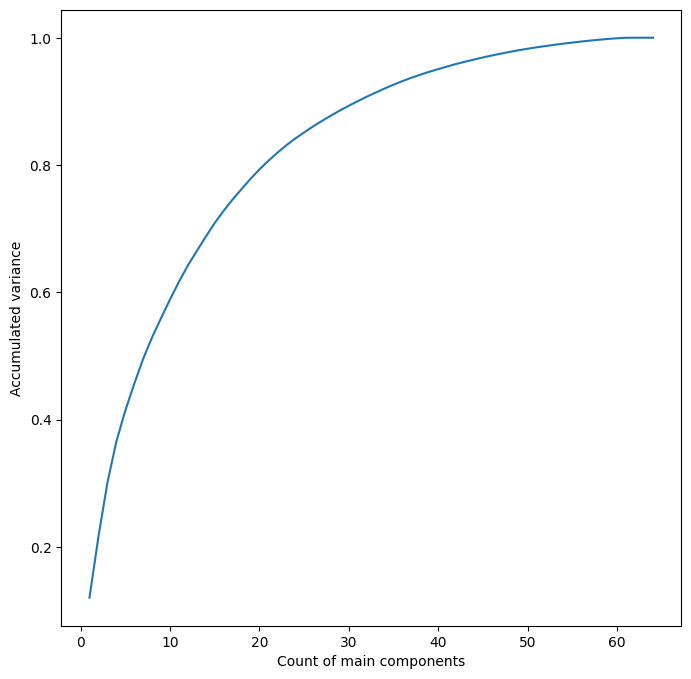

80% дисперсии -> 20 компонент
95% дисперсии -> 39 компонент
99% дисперсии -> 53 компонент


In [40]:
# Обучите PCA на всех компонентах
pca_full = PCA(n_components=64, random_state=42)
# YOUR CODE HERE
pca_full.fit(X_scaled)
# Вычислите накопленную объясняемую дисперсию
explained_variance = pca_full.explained_variance_ratio_
cumvar = np.cumsum(explained_variance)
n_components = np.arange(1, 65)
# Постройте график: по оси X — число компонент, по оси Y — cumvar
# Добавьте горизонтальные линии для 80%, 95%, 99%
# YOUR CODE HERE

fig, axes = plt.subplots(1, 1, figsize=(8,8))
axes.plot(n_components, cumvar)
axes.set_xlabel("Count of main components")
axes.set_ylabel("Accumulated variance")
plt.show()


# Найдите минимальное k для каждого порога
for threshold in [0.80, 0.95, 0.99]:
    for i in range(len(cumvar)):
        if cumvar[i] >= threshold:
            k = i
            print(f"{int(threshold*100)}% дисперсии -> {k} компонент")
            break

---
## Шаг 3. PCA для визуализации (2 компоненты)

Спроецируйте данные на 2 главных компоненты. Визуализируйте scatter plot с раскраской по классу.
Укажите долю объяснённой дисперсии на осях.

PC1: 12.0%
PC2: 9.6%
Итого: 21.6%


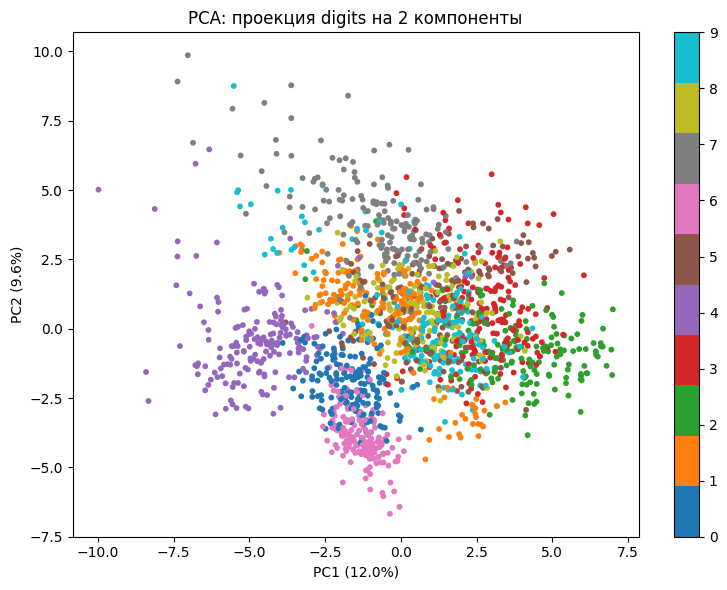

In [41]:
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

print(f"PC1: {pca2.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2: {pca2.explained_variance_ratio_[1]*100:.1f}%")
print(f"Итого: {pca2.explained_variance_ratio_.sum()*100:.1f}%")

plt.figure(figsize=(8, 6))
# YOUR CODE HERE: scatter с cmap='tab10', colorbar
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=y, cmap='tab10', s=10, marker='o')
plt.colorbar()
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA: проекция digits на 2 компоненты')
plt.tight_layout()
plt.show()

---
## Шаг 4. Интерпретация: loadings (нагрузки)

Visualizируйте нагрузки PC1 и PC2 как 8×8 изображения.
Яркие пиксели = сильное влияние на данную компоненту.
Используйте diverging colormap `'RdBu_r'`.

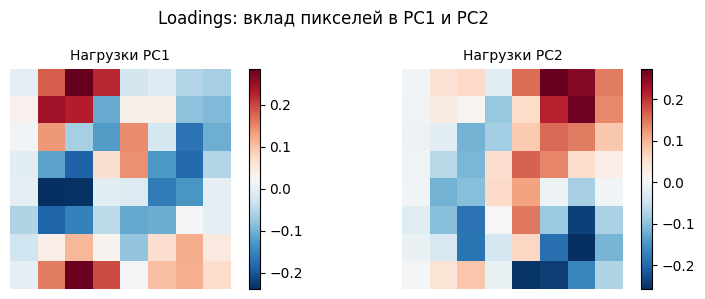

In [ ]:
# pca2.components_ имеет форму (2, 64)
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
pixels_components = {}
for i, ax in enumerate(axes):
    # YOUR CODE HERE
    # Подсказка: pca2.components_[i].reshape(8, 8)
    pixels_components[i] = pca2.components_[i].reshape(8, 8)
    im = ax.imshow(pixels_components[i], cmap='RdBu_r', interpolation='nearest')
    plt.colorbar(im, ax=ax)
    ax.set_title(f'Нагрузки PC{i+1}', fontsize=10)
    ax.axis('off')

plt.suptitle('Loadings: вклад пикселей в PC1 и PC2', fontsize=12)
plt.tight_layout()
plt.show()

### Вопрос: какие области изображения наиболее важны для PC1 и PC2?

Ответ: 

1) для PC1 преимущественно важна левая сторона изображения (углы имеют сильно положительный вклад пикселей, посередине - отрицательный). Крайний столбец пикселей почти не вносит вклад в изображение (возможно, связано с тем, как именно пишутся цифры человеком). Просматривается силуэт цифры 0.

2) для PC2 наоборот важна левая часть (противоположность поведения, скорее всего, обусловлена ортогональностью осей в пространстве): правый верхний угол имеет положиельный вклад пикселей, левый нижний - отрицательный. Проглядывается силуэт цифры 6.

---
## Шаг 5. PCA как препроцессинг для классификатора

Сравните качество LogisticRegression:
1. На исходных 64 признаках
2. На PCA 95% дисперсии
3. На PCA 80% дисперсии

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

results = {}

# --- Вариант 1: без PCA ---
clf_base = LogisticRegression(max_iter=1000, random_state=42)
# YOUR CODE HERE
clf_base.fit(X_train, y_train)
pred_base = clf_base.predict(X_test) 
results['Без PCA (64 признака)'] = accuracy_score(pred_base, y_test)

# --- Вариант 2: PCA с 95% дисперсии ---
# Подсказка: PCA(n_components=0.95) автоматически выбирает k
pca_95 = PCA(n_components=0.95, random_state=42)
X_train_95 = pca_95.fit_transform(X_train)
X_test_95  = pca_95.transform(X_test)
clf_95 = LogisticRegression(max_iter=1000, random_state=42)
# YOUR CODE HERE
clf_95.fit(X_train_95, y_train)
pred_95 = clf_95.predict(X_test_95) 
results[f'PCA 95% ({pca_95.n_components_} компонент)'] = accuracy_score(pred_95, y_test)

# --- Вариант 3: PCA с 80% дисперсии ---
pca_80 = PCA(n_components=0.80, random_state=42)
X_train_80 = pca_80.fit_transform(X_train)
X_test_80  = pca_80.transform(X_test)
clf_80 = LogisticRegression(max_iter=1000, random_state=42)
# YOUR CODE HERE
clf_80.fit(X_train_80, y_train)
pred_80 = clf_80.predict(X_test_80) 
results[f'PCA 80% ({pca_80.n_components_} компонент)'] = accuracy_score(pred_80, y_test)

print("Сравнение accuracy:")
print("-" * 45)
for name, acc in results.items():
    print(f"{name:35s}: {acc:.4f}")

Сравнение accuracy:
---------------------------------------------
Без PCA (64 признака)              : 0.9722
PCA 95% (40 компонент)             : 0.9639
PCA 80% (21 компонент)             : 0.9472


---
## Шаг 6. t-SNE: нелинейная визуализация

Рекомендуемый пайплайн: сначала PCA до 30 компонент, затем t-SNE. Это ускоряет работу и убирает шум.

После PCA(30): 89.6% дисперсии


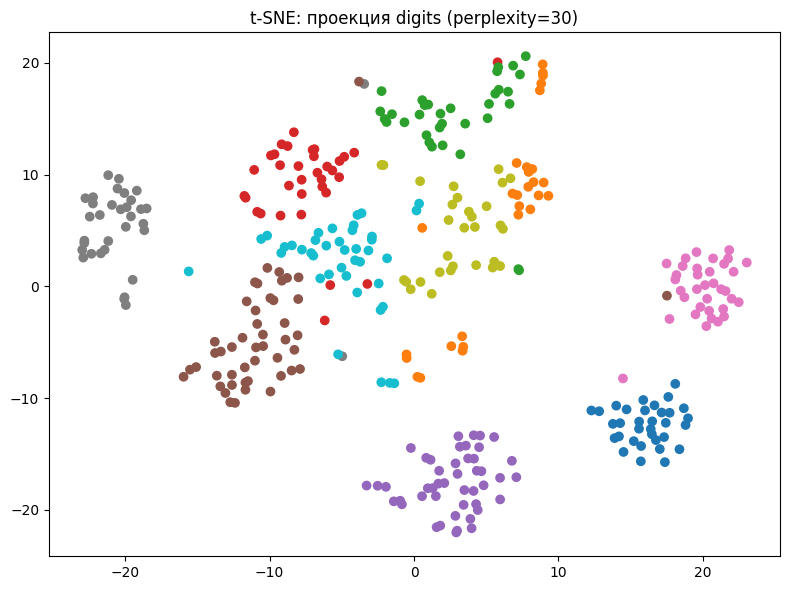

In [54]:
# PCA до 30 компонент (препроцессинг перед t-SNE)
pca_30 = PCA(n_components=30, random_state=42)
X_pca30_train = pca_30.fit_transform(X_train)
X_pca30_test = pca_30.transform(X_test)
print(f"После PCA(30): {pca_30.explained_variance_ratio_.sum()*100:.1f}% дисперсии")

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne_test = tsne.fit_transform(X_pca30_test)

plt.figure(figsize=(8, 6))
# YOUR CODE HERE: scatter с cmap='tab10'
plt.scatter(X_tsne_test[:, 0], X_tsne_test[:, 1], cmap='tab10', c=y_test)
plt.title('t-SNE: проекция digits (perplexity=30)')
plt.tight_layout()
plt.show()

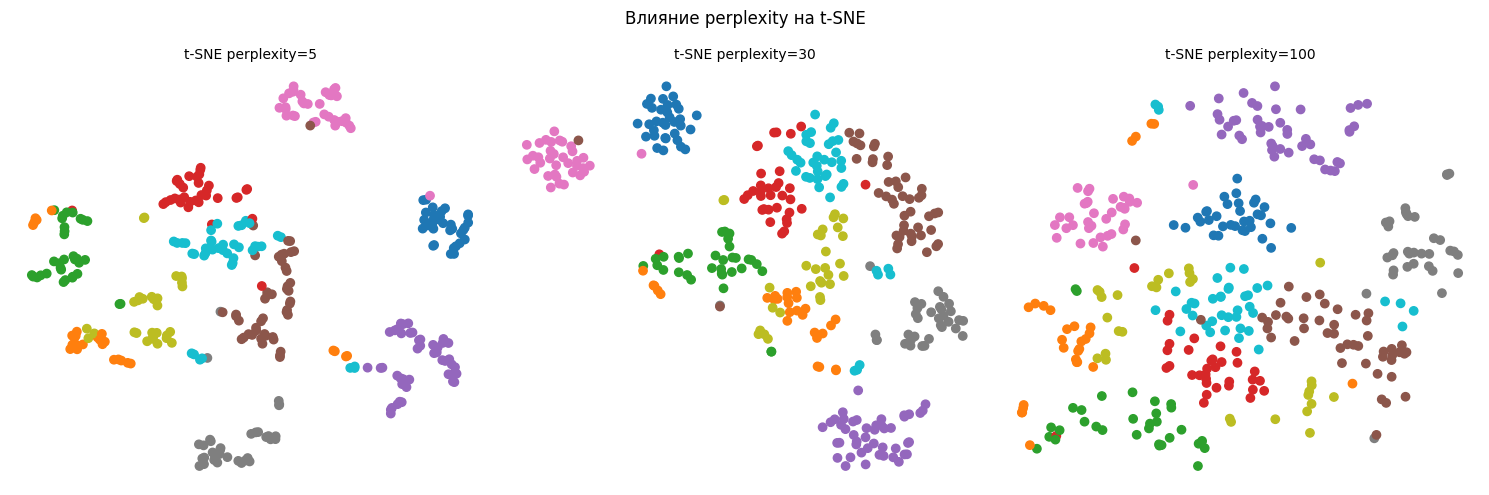

In [57]:
# Эксперимент с perplexity: 5, 30, 100
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, perp in zip(axes, [5, 30, 100]):
    tsne_p = TSNE(n_components=2, perplexity=perp, random_state=42)
    # YOUR CODE HERE: fit_transform и scatter
    X_tsne_perp_test = tsne_p.fit_transform(X_test)
    ax.scatter(X_tsne_perp_test[:, 0], X_tsne_perp_test[:, 1], cmap='tab10', c=y_test)
    ax.set_title(f't-SNE perplexity={perp}', fontsize=10)
    ax.axis('off')

plt.suptitle('Влияние perplexity на t-SNE', fontsize=12)
plt.tight_layout()
plt.show()

---
## Шаг 7. UMAP

Если не установлен: `pip install umap-learn`

In [ ]:
try:
    import umap
    UMAP_AVAILABLE = True
    print("umap-learn доступен")
except ImportError:
    print("Установите: pip install umap-learn")
    UMAP_AVAILABLE = False

if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    X_umap = # YOUR CODE HERE

    plt.figure(figsize=(8, 6))
    # YOUR CODE HERE: scatter
    plt.title('UMAP: проекция digits')
    plt.tight_layout()
    plt.show()

---
## Шаг 8. Сравнение проекций: PCA vs t-SNE vs UMAP

In [ ]:
n_plots = 3 if UMAP_AVAILABLE else 2
fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 5))

projections = [
    (X_pca2, 'PCA (2 компоненты)'),
    (X_tsne, 't-SNE (perplexity=30)'),
]
if UMAP_AVAILABLE:
    projections.append((X_umap, 'UMAP (n_neighbors=15)'))

for ax, (X_proj, title) in zip(axes, projections):
    scatter = ax.scatter(X_proj[:, 0], X_proj[:, 1],
                         c=y, cmap='tab10', s=10, alpha=0.7)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

handles, _ = scatter.legend_elements()
fig.legend(handles, [str(i) for i in range(10)],
           loc='lower center', ncol=10, title='Цифра',
           bbox_to_anchor=(0.5, -0.05))
plt.suptitle('Сравнение методов снижения размерности', fontsize=13)
plt.tight_layout()
plt.show()

---
## Шаг 9. Количественная оценка: Silhouette Score

In [ ]:
from sklearn.metrics import silhouette_score

scores = {}
scores['PCA (2 компоненты)'] = silhouette_score(X_pca2, y)
scores['t-SNE']               = # YOUR CODE HERE
if UMAP_AVAILABLE:
    scores['UMAP']            = # YOUR CODE HERE

print("Silhouette Score (выше = лучше):")
print("-" * 35)
for name, score in sorted(scores.items(), key=lambda x: -x[1]):
    print(f"{name:25s}: {score:.4f}")

---
## Шаг 10. Реконструкция из PCA

PCA позволяет восстановить исходные данные через `inverse_transform`. Посмотрим, как выглядит реконструкция при разном числе компонент.

In [ ]:
sample_idx = 0
x_original = X_scaled[sample_idx:sample_idx+1]

fig, axes = plt.subplots(1, 6, figsize=(13, 2.5))

# Оригинал
axes[0].imshow(scaler.inverse_transform(x_original).reshape(8, 8), cmap='gray_r')
axes[0].set_title('Оригинал', fontsize=9)
axes[0].axis('off')

for ax, k in zip(axes[1:], [2, 5, 10, 20, 40]):
    pca_k = PCA(n_components=k, random_state=42)
    pca_k.fit(X_scaled)
    # YOUR CODE HERE:
    # 1. Спроецируйте x_original: x_proj = pca_k.transform(x_original)
    # 2. Восстановите: x_rec = pca_k.inverse_transform(x_proj)
    # 3. Обратите стандартизацию: scaler.inverse_transform(x_rec)
    # 4. Отобразите как 8x8 изображение
    ax.set_title(f'k={k}', fontsize=9)
    ax.axis('off')

plt.suptitle('Реконструкция: влияние числа компонент', fontsize=11)
plt.tight_layout()
plt.show()

---
## Выводы

### Ваши выводы

**1. Число компонент PCA:**
- Для сохранения 80% дисперсии нужно ___ компонент из 64.
- Для сохранения 95% дисперсии нужно ___ компонент из 64.

**2. PCA как препроцессинг:**
- Accuracy без PCA: ___
- Accuracy с PCA (95%): ___
- Accuracy с PCA (80%): ___
- Вывод: _(PCA помогает / не влияет / снижает качество — и почему?)_

**3. Сравнение проекций:**
- Лучший Silhouette Score: ___ (метод: ___)
- Цифры, которые сложнее всего разделить: ___

**4. Вывод о методах:**
- _Когда применять PCA, а когда t-SNE/UMAP?_

Краткие выводы в конце:
   - сколько компонент PCA достаточно для сохранения 95% дисперсии?
   - как влияет PCA-препроцессинг на качество классификатора?
   - какой метод визуализации (PCA, t-SNE, UMAP) лучше разделяет классы?